[Success] Dashboard saved as 'ecommerce_dashboard.png'


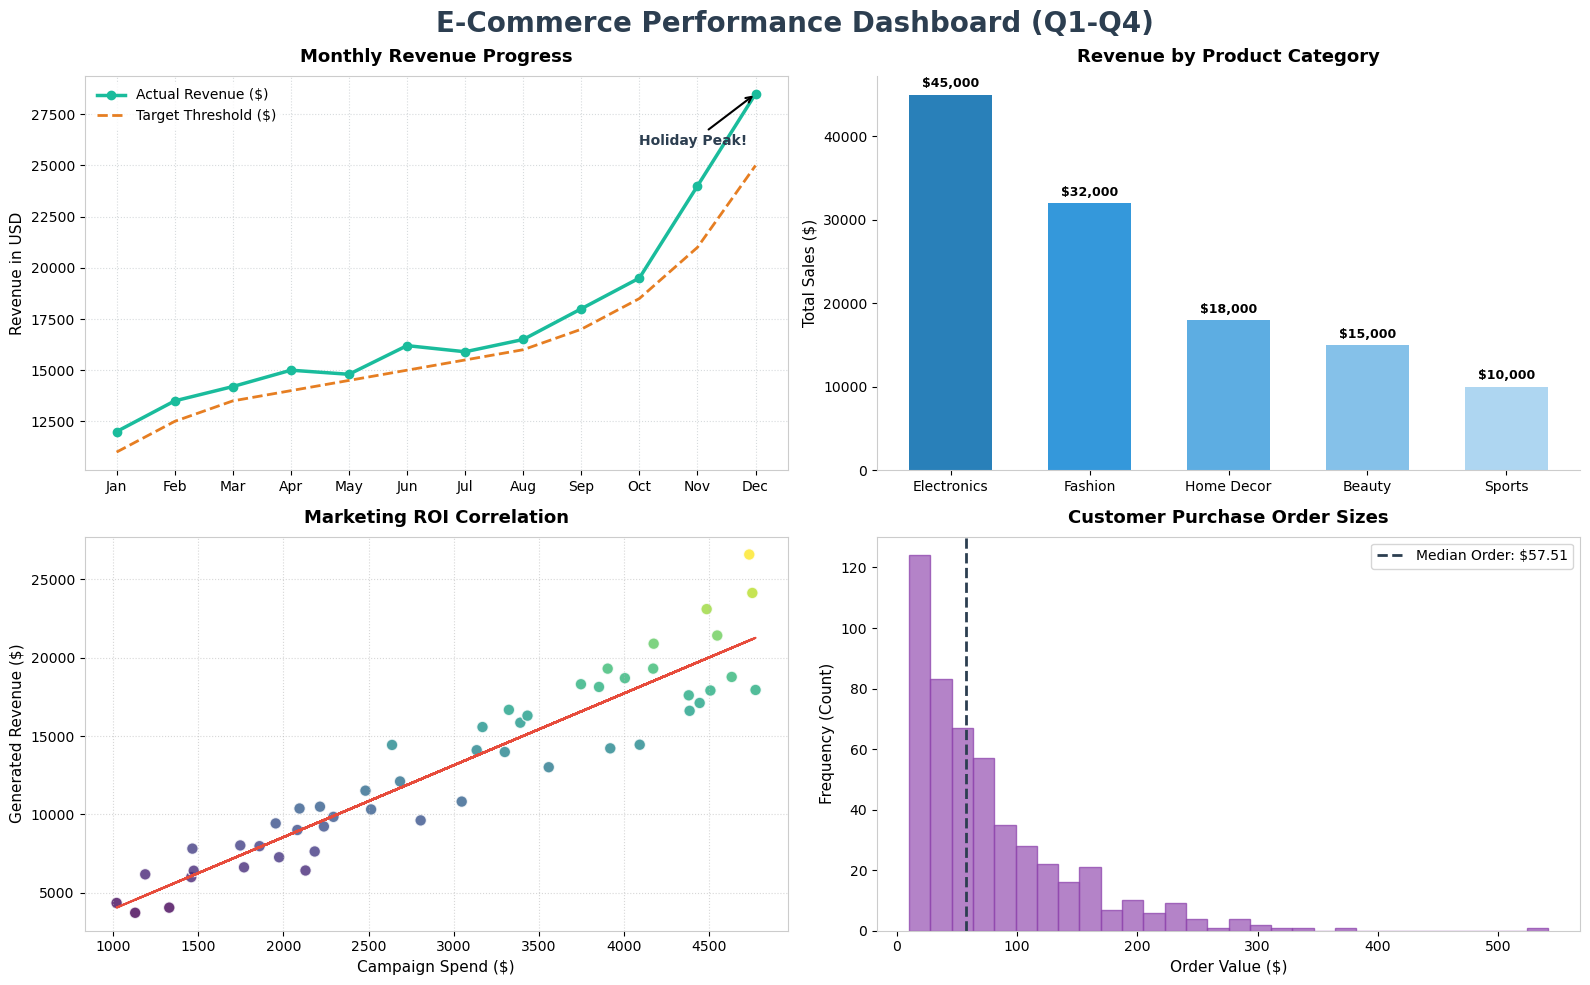

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 1. SETUP & SIMULATE REAL WORLD DATA
# ----------------------------------------------------
np.random.seed(42)
months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# Simulate Sales Trends (with a holiday season spike)
actual_sales = [
    12000,
    13500,
    14200,
    15000,
    14800,
    16200,
    15900,
    16500,
    18000,
    19500,
    24000,
    28500,
]
target_sales = [
    11000,
    12500,
    13500,
    14000,
    14500,
    15000,
    15500,
    16000,
    17000,
    18500,
    21000,
    25000,
]

# Simulate Category Shares
categories = ["Electronics", "Fashion", "Home Decor", "Beauty", "Sports"]
category_revenue = [45000, 32000, 18000, 15000, 10000]

# Simulate Marketing Spend vs Revenue (Scatter Data)
marketing_spend = np.random.randint(1000, 5000, 50)
revenue_generated = marketing_spend * np.random.uniform(3.5, 5.2, 50) + np.random.normal(
    0, 800, 50
)

# Simulate Order Values (Histogram Data)
order_values = np.random.exponential(scale=65, size=500) + 10

# ----------------------------------------------------
# 2. INITIALIZE MULTI-PANEL DASHBOARD (2x2 Grid)
# ----------------------------------------------------
# Use professional formatting configurations
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#CCCCCC"
plt.rcParams["axes.linewidth"] = 0.8

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "E-Commerce Performance Dashboard (Q1-Q4)",
    fontsize=20,
    fontweight="bold",
    color="#2C3E50",
    y=0.98,
)

# ----------------------------------------------------
# PLOT 1: Actual vs Target Sales (Line Chart)
# ----------------------------------------------------
ax1 = axs[0, 0]
ax1.plot(
    months,
    actual_sales,
    marker="o",
    linewidth=2.5,
    color="#1ABC9C",
    label="Actual Revenue ($)",
)
ax1.plot(
    months,
    target_sales,
    linestyle="--",
    linewidth=2,
    color="#E67E22",
    label="Target Threshold ($)",
)
ax1.set_title("Monthly Revenue Progress", fontsize=13, fontweight="bold", pad=10)
ax1.set_ylabel("Revenue in USD", fontsize=11)
ax1.grid(True, linestyle=":", alpha=0.6, color="#BDC3C7")
ax1.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

# Annotate highest sales month (December)
ax1.annotate(
    "Holiday Peak!",
    xy=("Dec", 28500),
    xytext=("Oct", 26000),
    arrowprops=dict(facecolor="#2C3E50", arrowstyle="->", lw=1.5),
    fontsize=10,
    fontweight="bold",
    color="#2C3E50",
)

# ----------------------------------------------------
# PLOT 2: Revenue Distribution By Product Category (Bar Chart)
# ----------------------------------------------------
ax2 = axs[0, 1]
colors = ["#2980B9", "#3498DB", "#5DADE2", "#85C1E9", "#AED6F1"]
bars = ax2.bar(categories, category_revenue, color=colors, width=0.6)
ax2.set_title("Revenue by Product Category", fontsize=13, fontweight="bold", pad=10)
ax2.set_ylabel("Total Sales ($)", fontsize=11)

# Add data value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax2.annotate(
        f"${height:,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),  # 3 points vertical offset
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="semibold",
    )

# Remove top and right borders for minimalist layout
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ----------------------------------------------------
# PLOT 3: Marketing Spend vs Revenue (Scatter Plot)
# ----------------------------------------------------
ax3 = axs[1, 0]
scatter = ax3.scatter(
    marketing_spend,
    revenue_generated,
    c=revenue_generated,
    cmap="viridis",
    alpha=0.8,
    edgecolors="w",
    s=70,
)
ax3.set_title("Marketing ROI Correlation", fontsize=13, fontweight="bold", pad=10)
ax3.set_xlabel("Campaign Spend ($)", fontsize=11)
ax3.set_ylabel("Generated Revenue ($)", fontsize=11)
ax3.grid(True, linestyle=":", alpha=0.5)

# Add trendline
m, b = np.polyfit(marketing_spend, revenue_generated, 1)
ax3.plot(
    marketing_spend,
    m * marketing_spend + b,
    color="#E74C3C",
    linewidth=1.5,
    label="ROI Trend",
)

# ----------------------------------------------------
# PLOT 4: Customer Order Value Distribution (Histogram)
# ----------------------------------------------------
ax4 = axs[1, 1]
n, bins, patches = ax4.hist(
    order_values, bins=30, color="#9B59B6", alpha=0.75, edgecolor="#8E44AD"
)
ax4.set_title(
    "Customer Purchase Order Sizes", fontsize=13, fontweight="bold", pad=10
)
ax4.set_xlabel("Order Value ($)", fontsize=11)
ax4.set_ylabel("Frequency (Count)", fontsize=11)

# Highlight Average Order Value (AOV) line
median_aov = np.median(order_values)
ax4.axvline(
    median_aov,
    color="#2C3E50",
    linestyle="dashed",
    linewidth=2,
    label=f"Median Order: ${median_aov:.2f}",
)
ax4.legend()

# ----------------------------------------------------
# 3. SAVE AND SHOW
# ----------------------------------------------------
plt.tight_layout()  # Prevents overlapping labels
plt.savefig("ecommerce_dashboard.png", dpi=300)  # High resolution save
print("[Success] Dashboard saved as 'ecommerce_dashboard.png'")
plt.show()
